In [1]:
import pickle
FILE_PATH = "data/"

with open(FILE_PATH+"training_X1.pkl", 'rb') as f:
    training_X_non_blocking = pickle.load(f)
with open(FILE_PATH+"training_Y1.pkl", 'rb') as f:
    training_Y_non_blocking = pickle.load(f)
with open(FILE_PATH+"training_X_blocking.pkl", 'rb') as f:
    training_X_blocking = pickle.load(f)
with open(FILE_PATH+"training_Y_blocking.pkl", 'rb') as f:
    training_Y_blocking = pickle.load(f)

print(training_X_non_blocking[0])
print(training_X_blocking)

[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
[[], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], [], [], [], [], [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [2]:
training_X = training_X_blocking + training_X_non_blocking
training_Y = training_Y_blocking + training_Y_non_blocking

In [3]:
n_users = len(training_X)

unique_users = [i for i in range(n_users)]

print(len(unique_users))
print(unique_users[:10])

42730
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [4]:
import pandas as pd

label_mapping = {
    (0,0) : 0,
    (1,0) : 1, #blockAB
    (0,1) : 2, #blockBA
    (1,1) : 3
}

training_df = pd.DataFrame([
    {
        "userID": user,
        "interaction_len": len(training_X[user]),
        "label": label_mapping.get(tuple(training_Y[user]), -1)
    }
    for user in unique_users
])

print(training_df.head(100))

    userID  interaction_len  label
0        0                0      1
1        1                1      1
2        2                0      1
3        3                1      1
4        4                0      1
..     ...              ...    ...
95      95                0      1
96      96                0      1
97      97                0      1
98      98                0      1
99      99                0      1

[100 rows x 3 columns]


In [5]:
train = training_df[["interaction_len"]]
test = training_df["label"]

train.head()
test.head()

0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(train, test, test_size=0.2, random_state=42)

# Create a logistic regression model (multiclass handled automatically)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)

# For multiclass, you need to specify averaging method
# Options: 'micro', 'macro', 'weighted'
precision_weighted = precision_score(y_test, y_pred, average='weighted')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

# Print individual metrics
print("="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (weighted): {recall_weighted:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print("="*50)

# For detailed per-class metrics
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred))

MODEL EVALUATION METRICS
Accuracy: 0.9430
Precision (weighted): 0.9415
Precision (macro): 0.6314
Recall (weighted): 0.9430
F1 Score (weighted): 0.9400
F1 Score (macro): 0.6303

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      4260
           1       0.99      0.90      0.94      4237
           3       0.00      0.00      0.00        49

    accuracy                           0.94      8546
   macro avg       0.63      0.63      0.63      8546
weighted avg       0.94      0.94      0.94      8546



/Users/luigizheng/Desktop/multidisciplinary-project/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/luigizheng/Desktop/multidisciplinary-project/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/luigizheng/Desktop/multidisciplinary-project/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average

LOGISTIC REGRESSION RESULTS
Accuracy: 0.9430
Precision: 0.9415
Recall: 0.9430
F1 score: 0.9400


/Users/luigizheng/Desktop/multidisciplinary-project/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


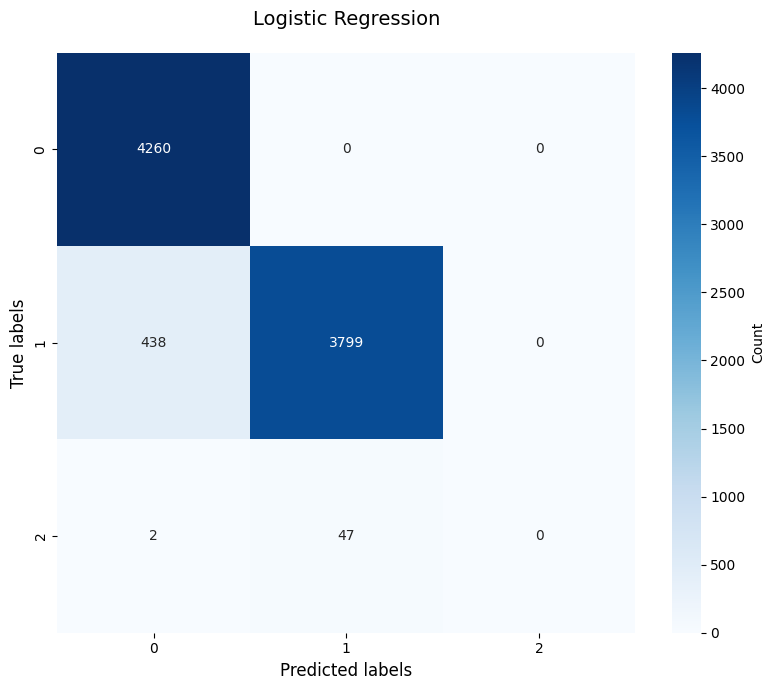

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
# Assuming you already have:
# cm = confusion_matrix(y_test, y_pred) from your logistic regression

# Generate confusion matrix (if not already done)
cm = confusion_matrix(y_test, y_pred)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Calculate metrics (like in your RNN example)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate overall metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 score: {f1:.4f}")
print("="*60)

# Visualise confusion matrix with same style as RNN
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted labels', fontsize=12)
plt.ylabel('True labels', fontsize=12)
plt.title('Logistic Regression', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Filtering the empty interactions

In [8]:
filtered = training_df[training_df["interaction_len"]>0]

In [9]:
train = filtered[["interaction_len"]]
test = filtered["label"]

train.head()
test.head()

1     1
3     1
8     1
18    1
21    1
Name: label, dtype: int64

In [ ]:
# Install scikit-learn if you don't have it:
# pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from imblearn.under_sampling import RandomUnderSampler

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(train, test, test_size=0.4, random_state=42)

# Balance classes to 50:50 ratio
rus = RandomUnderSampler(sampling_strategy={0: 800, 1: 800, 3: 9}, random_state=42)
#X_train, y_train = rus.fit_resample(X_train, y_train)
X_test, y_test = rus.fit_resample(X_test, y_test)

# Create a logistic regression model (multiclass handled automatically)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7265382224984462


/Users/luigizheng/Desktop/multidisciplinary-project/venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/luigizheng/Desktop/multidisciplinary-project/venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/luigizheng/Desktop/multidisciplinary-project/venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/luigizheng/Desktop/multidisciplinary-project/venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names`

In [42]:
blocking_lengths=[]
non_blocking_lengths=[]
for idx, row in X_train.iterrows():
    if y_train[idx]==1:
        blocking_lengths.append(row["interaction_len"])
    else:
        non_blocking_lengths.append(row["interaction_len"])

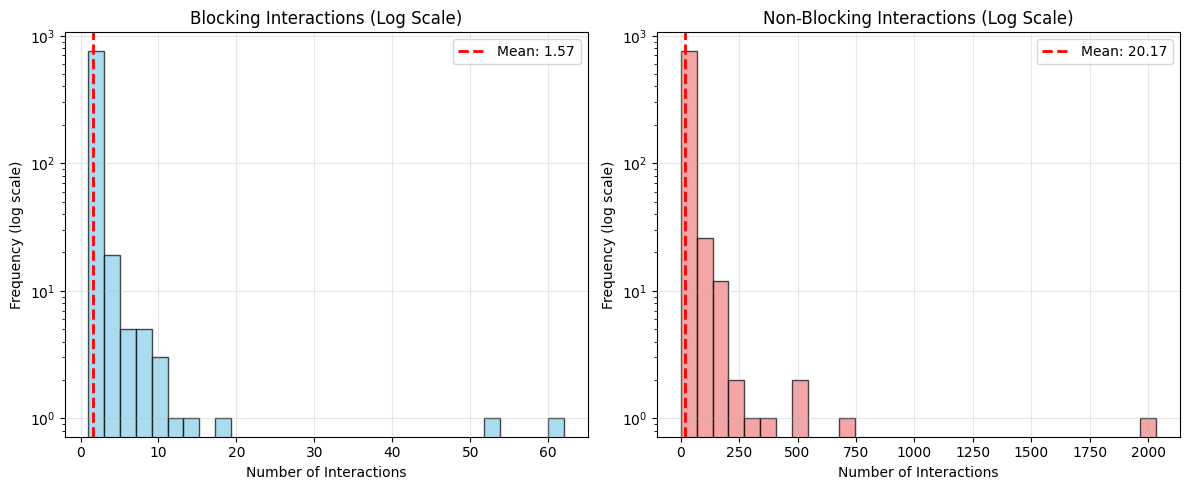

In [43]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Blocking histogram (log scale)
axes[0].hist(blocking_lengths, bins=30, alpha=0.7, color='skyblue', edgecolor='black', log=True)
axes[0].axvline(np.mean(blocking_lengths), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(blocking_lengths):.2f}')
axes[0].set_xlabel('Number of Interactions')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Blocking Interactions (Log Scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Non-blocking histogram (log scale)
axes[1].hist(non_blocking_lengths, bins=30, alpha=0.7, color='lightcoral', edgecolor='black', log=True)
axes[1].axvline(np.mean(non_blocking_lengths), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(non_blocking_lengths):.2f}')
axes[1].set_xlabel('Number of Interactions')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Non-Blocking Interactions (Log Scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

LOGISTIC REGRESSION RESULTS
Accuracy: 0.7265
Precision: 0.7779
Recall: 0.7265
F1 score: 0.7112


/Users/luigizheng/Desktop/multidisciplinary-project/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


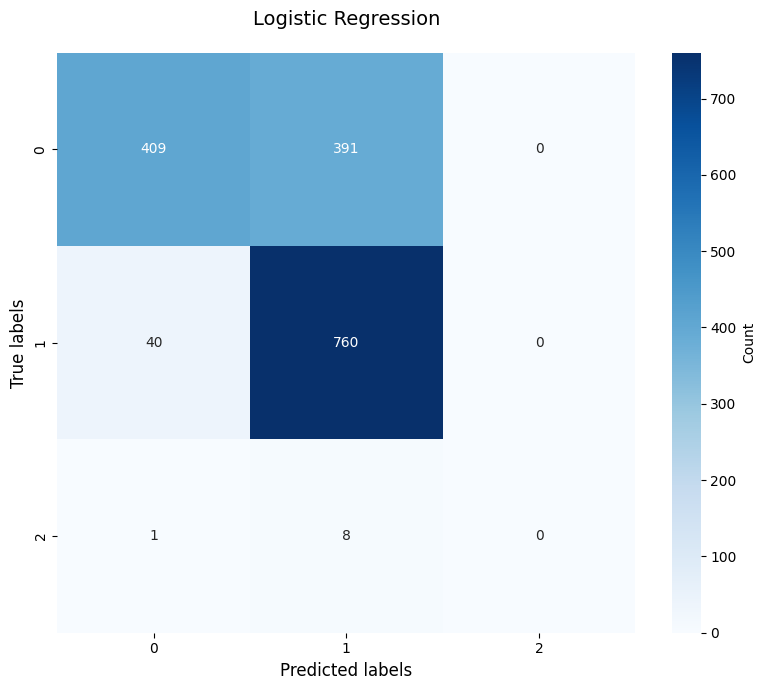

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
# Assuming you already have:
# cm = confusion_matrix(y_test, y_pred) from your logistic regression

# Generate confusion matrix (if not already done)
cm = confusion_matrix(y_test, y_pred)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Calculate metrics (like in your RNN example)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate overall metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 score: {f1:.4f}")
print("="*60)

# Visualise confusion matrix with same style as RNN
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted labels', fontsize=12)
plt.ylabel('True labels', fontsize=12)
plt.title('Logistic Regression', fontsize=14, pad=20)
plt.tight_layout()
plt.show()